# 📊 Análisis Descriptivo Completo — Students Social Media & Addiction

**Dataset:** Students Social Media & Relationships  
**Población:** Estudiantes de 16–25 años (High School, Undergraduate, Graduate)  
**Geografía:** Múltiples países — Encuesta Q1 2025  
**Registros:** 705 filas × 13 columnas
**Alumno:** Manuel Dieguez

---
### Índice
1. Importación y carga
2. Exploración inicial
3. Clasificación de variables
4. Estadísticas descriptivas
5. Duplicados
6. Valores nulos
7. Outliers (IQR + Z-Score)
8. Visualizaciones (6 gráficos)
9. Análisis de correlaciones
10. Resumen 

---
## 1. Importación y carga de datos

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as scipy_stats
import warnings

warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE_CAT = sns.color_palette('tab10')
PALETTE_SEQ = 'Blues'

# ── Carga ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('Students_Social_Media_Addiction.csv')
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 705 filas × 13 columnas


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


---
## 2. Exploración inicial

In [32]:
print('─' * 60)
print(f'  Filas          : {df.shape[0]}')
print(f'  Columnas       : {df.shape[1]}')
print(f'  Memoria aprox. : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('─' * 60)
df.info()

────────────────────────────────────────────────────────────
  Filas          : 705
  Columnas       : 13
  Memoria aprox. : 270.4 KB
────────────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    str    
 3   Academic_Level                705 non-null    str    
 4   Country                       705 non-null    str    
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    str    
 7   Affects_Academic_Performance  705 non-null    str    
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10

In [33]:
print('── Primeras 5 filas ──')
display(df.head())
print('── Últimas 5 filas ──')
display(df.tail())
print('── Muestra aleatoria (5 filas) ──')
display(df.sample(5, random_state=42))

── Primeras 5 filas ──


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


── Últimas 5 filas ──


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4
704,705,19,Female,Undergraduate,Poland,6.2,Facebook,Yes,6.3,5,Single,4,8


── Muestra aleatoria (5 filas) ──


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
478,479,20,Female,Undergraduate,France,3.0,Instagram,No,9.0,7,In Relationship,2,5
81,82,19,Female,Undergraduate,Azerbaijan,4.8,TikTok,Yes,5.7,6,Single,3,7
77,78,22,Female,Graduate,Kyrgyzstan,2.9,Facebook,No,7.0,7,In Relationship,2,5
208,209,19,Female,Undergraduate,Bangladesh,4.2,Instagram,Yes,7.8,5,Single,3,7
319,320,22,Male,Graduate,Germany,3.1,Facebook,No,8.4,8,In Relationship,1,4


---
## 3. Clasificación de variables

| Variable | Descripción |
|----------|-------------|
| Student_ID | Identificador único del encuestado |
| Age | Edad en años |
| Gender | "Masculino" o "Femenino" |
| Academic_Level | Secundaria / Grado / Posgrado |
| Country | País de residencia |
| Avg_Daily_Usage_Hours | Promedio de horas diarias en redes sociales |
| Most_Used_Platform | Instagram, Facebook, TikTok, etc. |
| Affects_Academic_Performance | Impacto autopercibido en el rendimiento académico (Sí/No) |
| Sleep_Hours_Per_Night | Promedio de horas de sueño por noche |
| Mental_Health_Score | Salud mental autoevaluada (1 = mala, 10 = excelente) |
| Relationship_Status | Soltero / En pareja / Complicado |
| Conflicts_Over_Social_Media | Cantidad de conflictos de pareja por uso de redes sociales |
| Addicted_Score | Puntaje de adicción a redes sociales (1 = bajo, 10 = alto) |



| Tipo | Variables | Descripción |
|------|-----------|-------------|
| **Identificador** | `Student_ID` | Clave única por estudiante |
| **Numéricas continuas** | `Age`, `Avg_Daily_Usage_Hours`, `Sleep_Hours_Per_Night` | Pueden tomar cualquier valor en un rango |
| **Numéricas discretas/scores** | `Mental_Health_Score`, `Conflicts_Over_Social_Media`, `Addicted_Score` | Valores enteros acotados |
| **Categóricas nominales** | `Gender`, `Country`, `Most_Used_Platform`, `Affects_Academic_Performance`, `Relationship_Status` | Sin orden intrínseco |
| **Categórica ordinal** | `Academic_Level` | High School < Undergraduate < Graduate |

In [34]:
# Clasificación automática
ID_COLS       = ['Student_ID']
NUM_CONT      = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']
NUM_DISC      = ['Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']
CAT_NOM       = ['Gender', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status']
CAT_ORD       = ['Academic_Level']
NUM_ALL       = NUM_CONT + NUM_DISC

print('NUMÉRICAS CONTINUAS  :', NUM_CONT)
print('NUMÉRICAS DISCRETAS  :', NUM_DISC)
print('CATEGÓRICAS NOMINALES:', CAT_NOM)
print('CATEGÓRICAS ORDINALES:', CAT_ORD)

print('\nCardinalidad de variables categóricas:')
for col in CAT_NOM + CAT_ORD:
    vals = df[col].value_counts()
    print(f'  {col:<35} → {df[col].nunique():>3} únicos   | top: {vals.index[0]} ({vals.iloc[0]})')

NUMÉRICAS CONTINUAS  : ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']
NUMÉRICAS DISCRETAS  : ['Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']
CATEGÓRICAS NOMINALES: ['Gender', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status']
CATEGÓRICAS ORDINALES: ['Academic_Level']

Cardinalidad de variables categóricas:
  Gender                              →   2 únicos   | top: Female (353)
  Country                             → 110 únicos   | top: India (53)
  Most_Used_Platform                  →  12 únicos   | top: Instagram (249)
  Affects_Academic_Performance        →   2 únicos   | top: Yes (453)
  Relationship_Status                 →   3 únicos   | top: Single (384)
  Academic_Level                      →   3 únicos   | top: Undergraduate (353)


---
## 4. Estadísticas descriptivas

In [35]:
# Variables numéricas — estadísticas extendidas
desc = df[NUM_ALL].describe().T
desc['skewness'] = df[NUM_ALL].skew().round(3)
desc['kurtosis'] = df[NUM_ALL].kurtosis().round(3)
desc['CV (%)']   = (df[NUM_ALL].std() / df[NUM_ALL].mean() * 100).round(1)  # Coef. variación
print('── Estadísticas descriptivas EXTENDIDAS — Variables NUMÉRICAS ──')
display(desc.round(3))

── Estadísticas descriptivas EXTENDIDAS — Variables NUMÉRICAS ──


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,CV (%)
Age,705.0,20.660,1.399,18.0,19.0,21.0,22.0,24.0,0.369,-0.508,6.8
Avg_Daily_Usage_Hours,705.0,4.919,1.257,1.5,4.1,4.8,5.8,8.5,0.165,-0.353,25.6
Sleep_Hours_Per_Night,705.0,6.869,1.127,3.8,6.0,6.9,7.7,9.6,-0.109,-0.520,16.4
Mental_Health_Score,705.0,6.227,1.105,4.0,5.0,6.0,7.0,9.0,0.049,-0.836,17.7
Conflicts_Over_Social_Media,705.0,2.850,0.958,0.0,2.0,3.0,4.0,5.0,-0.162,-0.383,33.6
Addicted_Score,705.0,6.437,1.587,2.0,5.0,7.0,8.0,9.0,-0.297,-0.894,24.7


---
## 4b. Análisis de forma — Skewness y Kurtosis

La **asimetría (skewness)** mide el sesgo de la distribución respecto a la media:
- `|skewness| < 0.5` → distribución aproximadamente simétrica
- `0.5 < |skewness| < 1` → distribución moderadamente asimétrica
- `|skewness| > 1` → distribución altamente asimétrica

La **curtosis excedente (excess kurtosis)** describe el peso de las colas respecto a una distribución normal:
- `≈ 0` → mesocúrtica (similar a la normal)
- `> 0` → leptocúrtica (colas pesadas, más valores extremos)
- `< 0` → platicúrtica (colas livianas, valores concentrados al centro)

In [36]:
from scipy.stats import skew, kurtosis

shape_data = []
for col in NUM_ALL:
    serie = df[col].dropna()
    sk  = skew(serie)
    ku  = kurtosis(serie)  # excess kurtosis (Fisher)

    if abs(sk) < 0.5:           sk_tipo = 'Simétrica'
    elif 0.5 < abs(sk) < 1:     sk_tipo = 'Asimetría moderada'
    else:                       sk_tipo = 'Asimetría alta'

    if abs(ku) < 0.2:   ku_tipo = 'Mesocúrtica'
    elif ku > 0:         ku_tipo = 'Leptocúrtica'
    else:                ku_tipo = 'Platicúrtica'

    shape_data.append({
        'Variable': col,
        'Skewness': round(sk, 4),
        'Tipo skewness': sk_tipo,
        'Kurtosis exc.': round(ku, 4),
        'Tipo kurtosis': ku_tipo,
        'Media': round(serie.mean(), 3),
        'Mediana': round(serie.median(), 3),
        'Dif. Media-Mediana': round(serie.mean() - serie.median(), 3)
    })

df_shape = pd.DataFrame(shape_data).set_index('Variable')
print('── Tabla de forma de distribuciones ──')
display(df_shape)

── Tabla de forma de distribuciones ──


,Skewness,Tipo skewness,Kurtosis exc.,Tipo kurtosis,Media,Mediana,Dif. Media-Mediana
Variable,,,,,,,
Age,0.3681,Simétrica,-0.5127,Platicúrtica,20.660,21.0,-0.340
Avg_Daily_Usage_Hours,0.1643,Simétrica,-0.3586,Platicúrtica,4.919,4.8,0.119
Sleep_Hours_Per_Night,-0.1088,Simétrica,-0.5246,Platicúrtica,6.869,6.9,-0.031
Mental_Health_Score,0.0489,Simétrica,-0.8382,Platicúrtica,6.227,6.0,0.227
Conflicts_Over_Social_Media,-0.1620,Simétrica,-0.3892,Platicúrtica,2.850,3.0,-0.150
Addicted_Score,-0.2962,Simétrica,-0.8967,Platicúrtica,6.437,7.0,-0.563


In [37]:
def interpretar_forma(col, sk, ku, media, mediana, std):
    """Genera un texto interpretativo automático para skewness y kurtosis."""
    lineas = []

    # --- Skewness ---
    if abs(sk) < 0.5:
        lineas.append(
            f"  Asimetría: distribución prácticamente simétrica (skewness = {sk:.3f}). "
            f"La media ({media:.2f}) y la mediana ({mediana:.2f}) son muy similares, "
            f"lo que indica una distribución equilibrada sin sesgo relevante."
        )
    elif sk > 0.5:
        lineas.append(
            f"  Asimetría: sesgo positivo (skewness = {sk:.3f}). "
            f"La cola derecha es más larga: existen estudiantes con valores inusualmente "
            f"altos que elevan la media ({media:.2f}) por encima de la mediana ({mediana:.2f}). "
            f"Esto sugiere la presencia de outliers hacia valores altos."
        )
    else:
        lineas.append(
            f"  Asimetría: sesgo negativo (skewness = {sk:.3f}). "
            f"La cola izquierda es más larga: existen estudiantes con valores inusualmente "
            f"bajos que arrastran la media ({media:.2f}) por debajo de la mediana ({mediana:.2f})."
        )

    # --- Kurtosis ---
    if abs(ku) < 0.5:
        lineas.append(
            f"  Curtosis: mesocúrtica (kurtosis exc. = {ku:.3f}). "
            f"La forma es similar a una distribución normal, sin colas especialmente "
            f"pesadas ni livianas."
        )
    elif ku > 0.5:
        lineas.append(
            f"  Curtosis: leptocúrtica (kurtosis exc. = {ku:.3f}). "
            f"La distribución es más apuntada que la normal, con colas más pesadas: "
            f"hay mayor probabilidad de valores extremos respecto a lo esperado en una normal."
        )
    else:
        lineas.append(
            f"  Curtosis: platicúrtica (kurtosis exc. = {ku:.3f}). "
            f"La distribución es más achatada que la normal, con colas más livianas: "
            f"los valores tienden a concentrarse cerca del centro sin extremos marcados."
        )

    # --- Recomendación estadística ---
    if abs(sk) > 1 or abs(ku) > 1:
        lineas.append(
            f"  Recomendación: dado el alejamiento de la normalidad, se sugiere usar "
            f"tests no paramétricos (Mann-Whitney, Kruskal-Wallis) o aplicar "
            f"transformaciones (log, raíz cuadrada) antes de modelar."
        )
    else:
        lineas.append(
            f"  Recomendación: la forma es compatible con el uso de métodos estadísticos "
            f"paramétricos estándar (t-test, ANOVA, regresión lineal)."
        )

    return '\n'.join(lineas)


print('=' * 70)
print('  INTERPRETACIÓN AUTOMÁTICA — FORMA DE LAS DISTRIBUCIONES')
print('=' * 70)

for col in NUM_ALL:
    serie = df[col].dropna()
    sk  = skew(serie)
    ku  = kurtosis(serie)
    print(f'\n▶ {col}')
    print('─' * 50)
    print(interpretar_forma(col, sk, ku, serie.mean(), serie.median(), serie.std()))

  INTERPRETACIÓN AUTOMÁTICA — FORMA DE LAS DISTRIBUCIONES

▶ Age
──────────────────────────────────────────────────
  Asimetría: distribución prácticamente simétrica (skewness = 0.368). La media (20.66) y la mediana (21.00) son muy similares, lo que indica una distribución equilibrada sin sesgo relevante.
  Curtosis: platicúrtica (kurtosis exc. = -0.513). La distribución es más achatada que la normal, con colas más livianas: los valores tienden a concentrarse cerca del centro sin extremos marcados.
  Recomendación: la forma es compatible con el uso de métodos estadísticos paramétricos estándar (t-test, ANOVA, regresión lineal).

▶ Avg_Daily_Usage_Hours
──────────────────────────────────────────────────
  Asimetría: distribución prácticamente simétrica (skewness = 0.164). La media (4.92) y la mediana (4.80) son muy similares, lo que indica una distribución equilibrada sin sesgo relevante.
  Curtosis: mesocúrtica (kurtosis exc. = -0.359). La forma es similar a una distribución normal, si

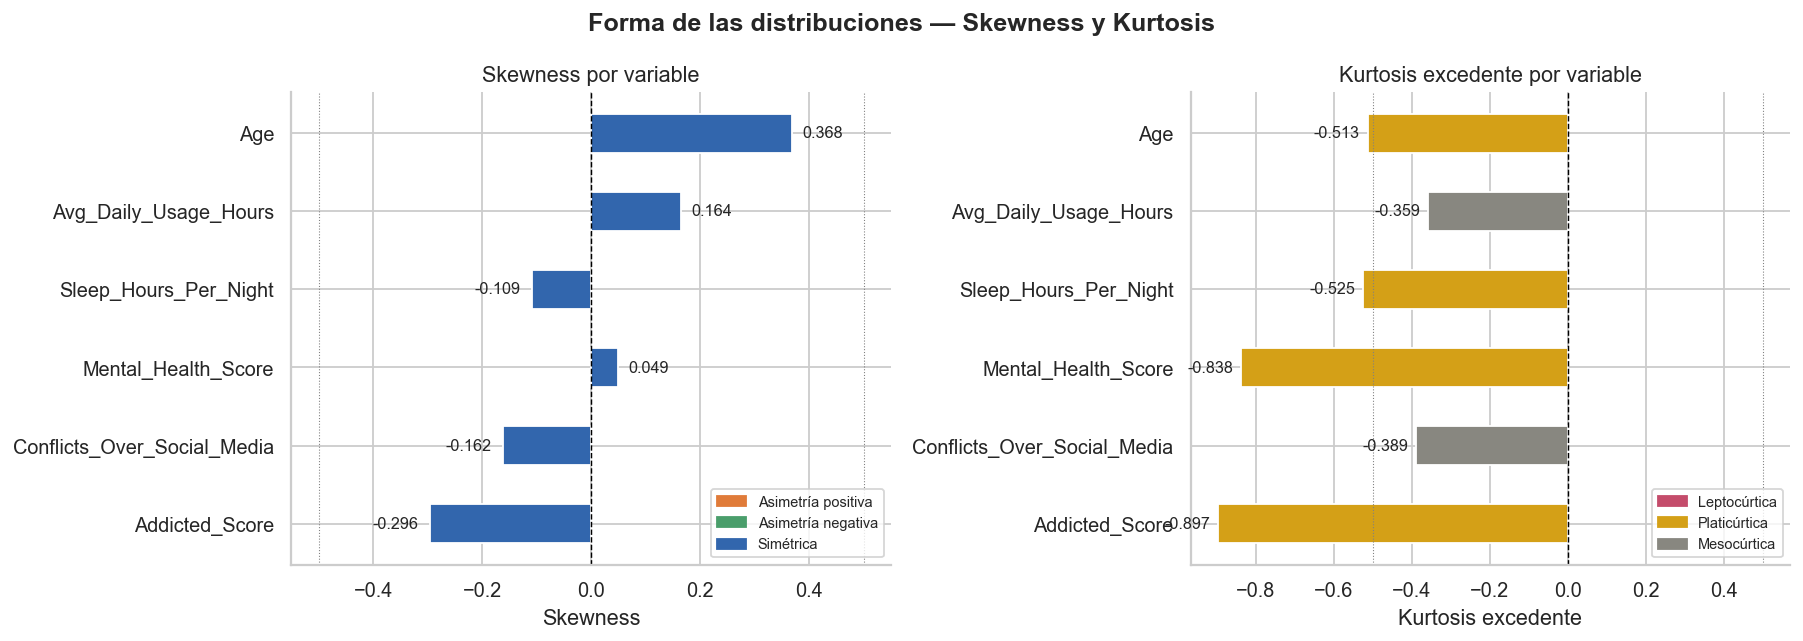

In [38]:
# Gráfico visual de skewness y kurtosis por variable
ncols_plot = [c for c in NUM_ALL if c != 'Student_ID']
sk_vals  = [skew(df[c].dropna()) for c in ncols_plot]
ku_vals  = [kurtosis(df[c].dropna()) for c in ncols_plot]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Skewness ──
colors_sk = ['#e07b39' if v > 0.5 else '#4a9e6b' if v < -0.5 else '#3266ad' for v in sk_vals]
bars = axes[0].barh(ncols_plot, sk_vals, color=colors_sk, edgecolor='white', height=0.5)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(0.5,  color='gray', linewidth=0.6, linestyle=':', label='Umbral ±0.5')
axes[0].axvline(-0.5, color='gray', linewidth=0.6, linestyle=':')
for bar, val in zip(bars, sk_vals):
    axes[0].text(
        val + (0.02 if val >= 0 else -0.02),
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )
axes[0].set_title('Skewness por variable', fontsize=12)
axes[0].set_xlabel('Skewness')
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# ── Kurtosis ──
colors_ku = ['#c44c6b' if v > 0.5 else '#d4a017' if v < -0.5 else '#888780' for v in ku_vals]
bars2 = axes[1].barh(ncols_plot, ku_vals, color=colors_ku, edgecolor='white', height=0.5)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(0.5,  color='gray', linewidth=0.6, linestyle=':', label='Umbral ±0.5')
axes[1].axvline(-0.5, color='gray', linewidth=0.6, linestyle=':')
for bar, val in zip(bars2, ku_vals):
    axes[1].text(
        val + (0.02 if val >= 0 else -0.02),
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )
axes[1].set_title('Kurtosis excedente por variable', fontsize=12)
axes[1].set_xlabel('Kurtosis excedente')
axes[1].legend(fontsize=9)
axes[1].invert_yaxis()

# Leyendas de color
from matplotlib.patches import Patch
leg_sk = [Patch(color='#e07b39', label='Asimetría positiva'),
          Patch(color='#4a9e6b', label='Asimetría negativa'),
          Patch(color='#3266ad', label='Simétrica')]
leg_ku = [Patch(color='#c44c6b', label='Leptocúrtica'),
          Patch(color='#d4a017', label='Platicúrtica'),
          Patch(color='#888780', label='Mesocúrtica')]
axes[0].legend(handles=leg_sk, fontsize=8, loc='lower right')
axes[1].legend(handles=leg_ku, fontsize=8, loc='lower right')

fig.suptitle('Forma de las distribuciones — Skewness y Kurtosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# Variables categóricas
print('── Frecuencias — Variables CATEGÓRICAS ──')
for col in CAT_NOM + CAT_ORD:
    if df[col].nunique() <= 15:
        freq = df[col].value_counts(dropna=False)
        pct  = (freq / len(df) * 100).round(1)
        tabla = pd.DataFrame({'Frecuencia': freq, '%': pct})
        print(f'\n{col}:')
        display(tabla)

── Frecuencias — Variables CATEGÓRICAS ──

Gender:


,Frecuencia,%
Gender,,
Female,353,50.1
Male,352,49.9



Most_Used_Platform:


,Frecuencia,%
Most_Used_Platform,,
Instagram,249,35.3
TikTok,154,21.8
Facebook,123,17.4
WhatsApp,54,7.7
Twitter,30,4.3
LinkedIn,21,3.0
WeChat,15,2.1
Snapchat,13,1.8
LINE,12,1.7



Affects_Academic_Performance:


,Frecuencia,%
Affects_Academic_Performance,,
Yes,453,64.3
No,252,35.7



Relationship_Status:


,Frecuencia,%
Relationship_Status,,
Single,384,54.5
In Relationship,289,41.0
Complicated,32,4.5



Academic_Level:


,Frecuencia,%
Academic_Level,,
Undergraduate,353,50.1
Graduate,325,46.1
High School,27,3.8


---
## 5. Detección de duplicados

In [40]:
n_dup      = df.duplicated().sum()
n_dup_id   = df['Student_ID'].duplicated().sum()
n_dup_excl = df.drop(columns='Student_ID').duplicated().sum()  # sin ID

print(f'Filas completamente duplicadas         : {n_dup}')
print(f'Student_ID duplicados                  : {n_dup_id}')
print(f'Duplicados (excluyendo Student_ID)     : {n_dup_excl}')

if n_dup == 0:
    print('\n✅ Sin duplicados en el dataset.')
else:
    print('\n⚠️  Duplicados encontrados:')
    display(df[df.duplicated(keep=False)])

Filas completamente duplicadas         : 0
Student_ID duplicados                  : 0
Duplicados (excluyendo Student_ID)     : 1

✅ Sin duplicados en el dataset.


---
## 6. Detección de valores nulos

In [41]:
nulos      = df.isnull().sum()
pct_nulos  = (nulos / len(df) * 100).round(2)
completitud = (1 - nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Completitud (%)': completitud.round(2)
}).sort_values('Nulos', ascending=False)

display(resumen_nulos)

print(f'\nTotal de celdas  : {df.shape[0] * df.shape[1]:,}')
print(f'Total con nulos  : {nulos.sum():,}')
print(f'Completitud gral : {(1 - nulos.sum() / (df.shape[0]*df.shape[1]))*100:.2f}%')

if nulos.sum() == 0:
    print('\n✅ Dataset 100% completo, sin valores nulos.')

,Nulos,Porcentaje (%),Completitud (%)
Student_ID,0,0.0,100.0
Age,0,0.0,100.0
Gender,0,0.0,100.0
Academic_Level,0,0.0,100.0
Country,0,0.0,100.0
Avg_Daily_Usage_Hours,0,0.0,100.0
Most_Used_Platform,0,0.0,100.0
Affects_Academic_Performance,0,0.0,100.0
Sleep_Hours_Per_Night,0,0.0,100.0
Mental_Health_Score,0,0.0,100.0



Total de celdas  : 9,165
Total con nulos  : 0
Completitud gral : 100.00%

✅ Dataset 100% completo, sin valores nulos.


---
## 7. Detección de outliers (IQR + Z-Score)

## Detección de outliers: IQR y Z-Score

### IQR (Rango Intercuartílico)
Mide el rango del 50% central de los datos. Un valor es outlier si cae fuera de los límites de Tukey:
- `Límite inferior = Q1 − 1.5 × IQR`
- `Límite superior = Q3 + 1.5 × IQR`

No asume ninguna distribución → ideal para datos asimétricos o muestras pequeñas.

### Z-Score
Encontre este metodo en internet y me parecio una forma interesante de buscar outliers. Mide cuántos desvíos estándar se aleja un valor de la media:
- `Z = (x − μ) / σ`
- Se considera outlier si `|Z| > 3`

Tiene la ventaja de cuantificar qué tan extremo es el outlier.


In [42]:
resultados_outliers = []

for col in NUM_ALL:
    serie = df[col].dropna()

    # Método IQR
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr, upper_iqr = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_iqr = ((serie < lower_iqr) | (serie > upper_iqr)).sum()

    # Método Z-Score
    z = np.abs(scipy_stats.zscore(serie))
    n_z = (z > 3).sum()

    resultados_outliers.append({
        'Variable': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
        'Límite inf. (IQR)': round(lower_iqr,2), 'Límite sup. (IQR)': round(upper_iqr,2),
        'Outliers IQR': n_iqr, '% IQR': round(n_iqr/len(serie)*100,2),
        'Outliers Z>3': n_z, '% Z': round(n_z/len(serie)*100,2)
    })

df_out = pd.DataFrame(resultados_outliers).set_index('Variable')
print('── Detección de outliers ──')
display(df_out)

── Detección de outliers ──


,Q1,Q3,IQR,Límite inf. (IQR),Límite sup. (IQR),Outliers IQR,% IQR,Outliers Z>3,% Z
Variable,,,,,,,,,
Age,19.0,22.0,3.0,14.50,26.50,0,0.00,0,0.0
Avg_Daily_Usage_Hours,4.1,5.8,1.7,1.55,8.35,3,0.43,0,0.0
Sleep_Hours_Per_Night,6.0,7.7,1.7,3.45,10.25,0,0.00,0,0.0
Mental_Health_Score,5.0,7.0,2.0,2.00,10.00,0,0.00,0,0.0
Conflicts_Over_Social_Media,2.0,4.0,2.0,-1.00,7.00,0,0.00,0,0.0
Addicted_Score,5.0,8.0,3.0,0.50,12.50,0,0.00,0,0.0


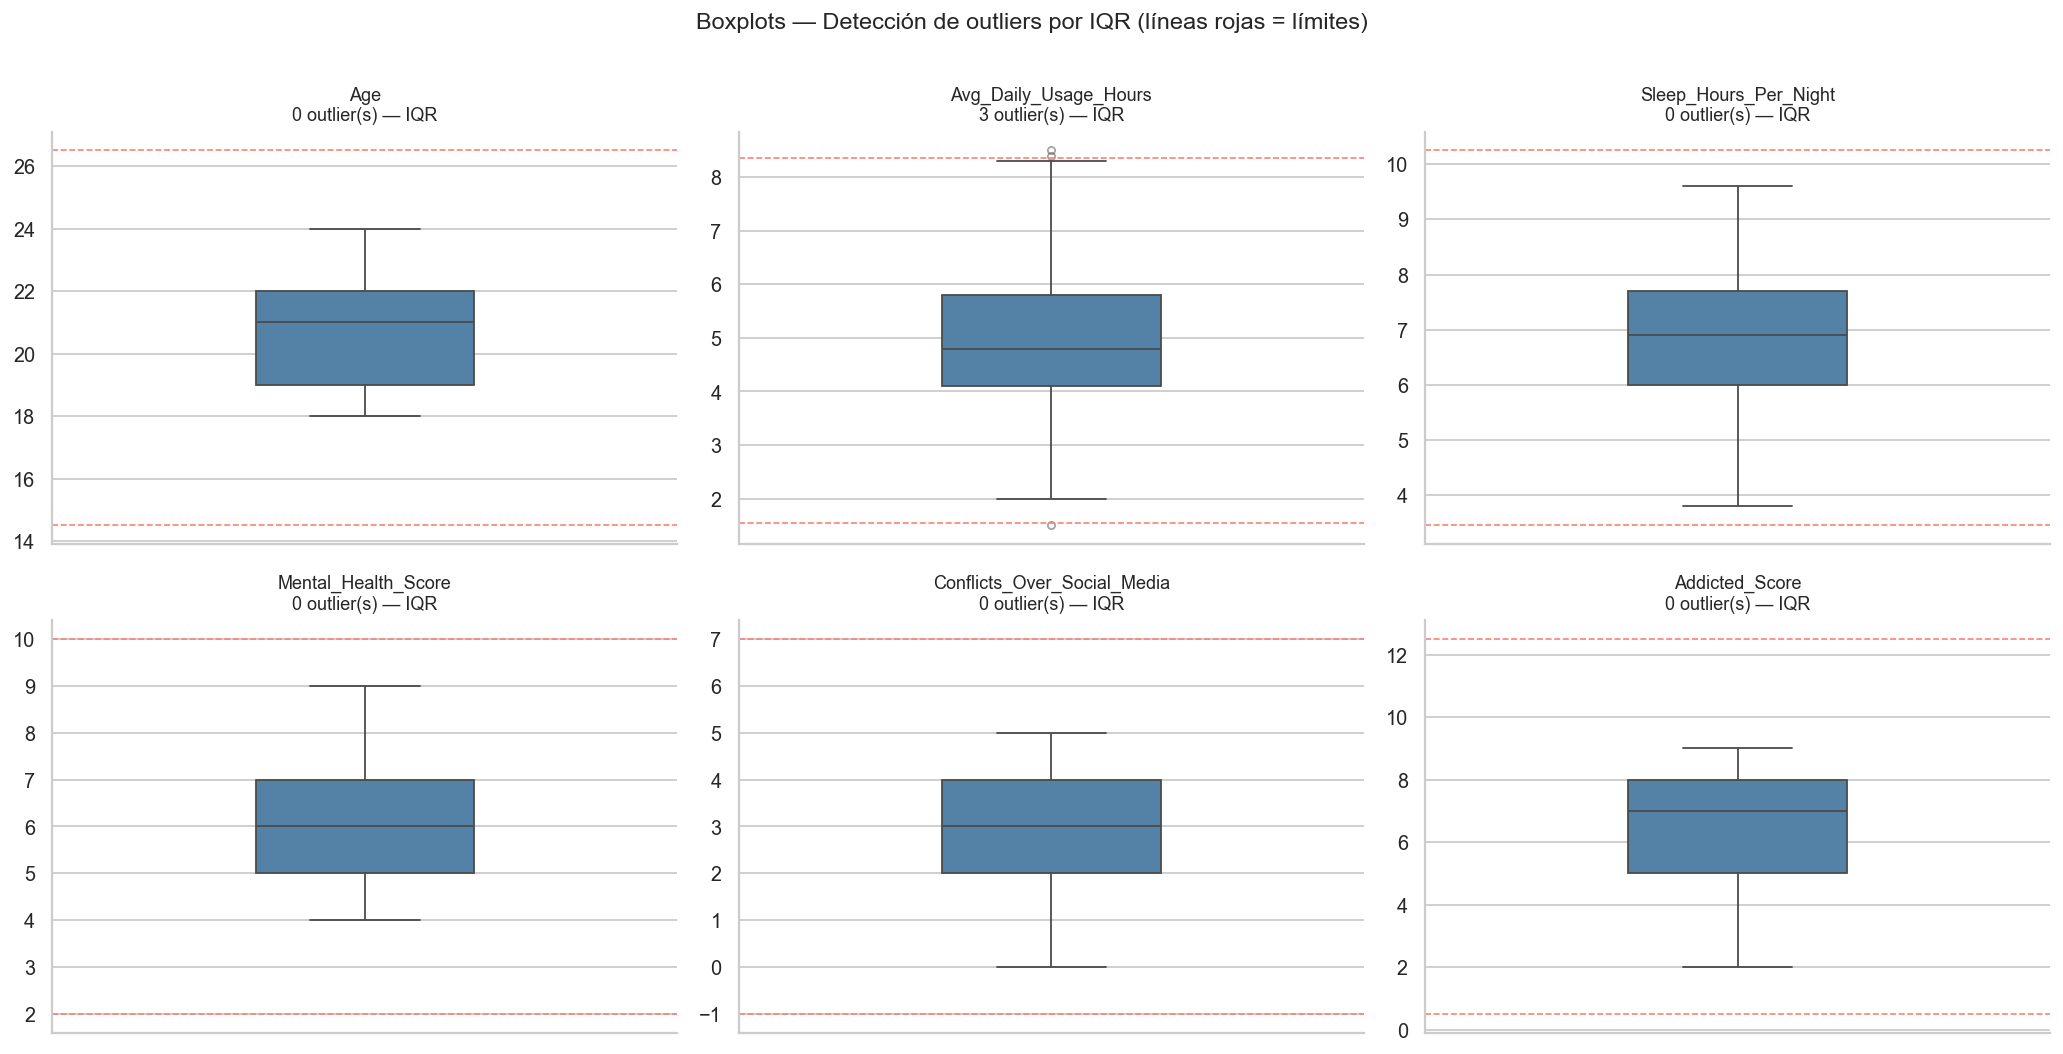

In [43]:
# Boxplots de outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(NUM_ALL):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()

    sns.boxplot(
        y=df[col], ax=axes[i], color='steelblue', width=0.35,
        flierprops=dict(marker='o', color='crimson', alpha=0.5, markersize=4)
    )
    axes[i].set_title(f'{col}\n{n_out} outlier(s) — IQR', fontsize=10)
    axes[i].set_ylabel('')

    # Líneas de límite
    axes[i].axhline(Q1 - 1.5*IQR, color='salmon', linestyle='--', linewidth=0.9, label='Límite IQR')
    axes[i].axhline(Q3 + 1.5*IQR, color='salmon', linestyle='--', linewidth=0.9)

fig.suptitle('Boxplots — Detección de outliers por IQR (líneas rojas = límites)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Donde no coincide la linea naranja con los limites del boxplot, es porque los datos no llegan al limite IQR, y la linea negra queda en el dato mas "alejado" del dataset

---
## 8. Visualizaciones

### 📊 Gráfico 1 — Distribución de Addicted Score

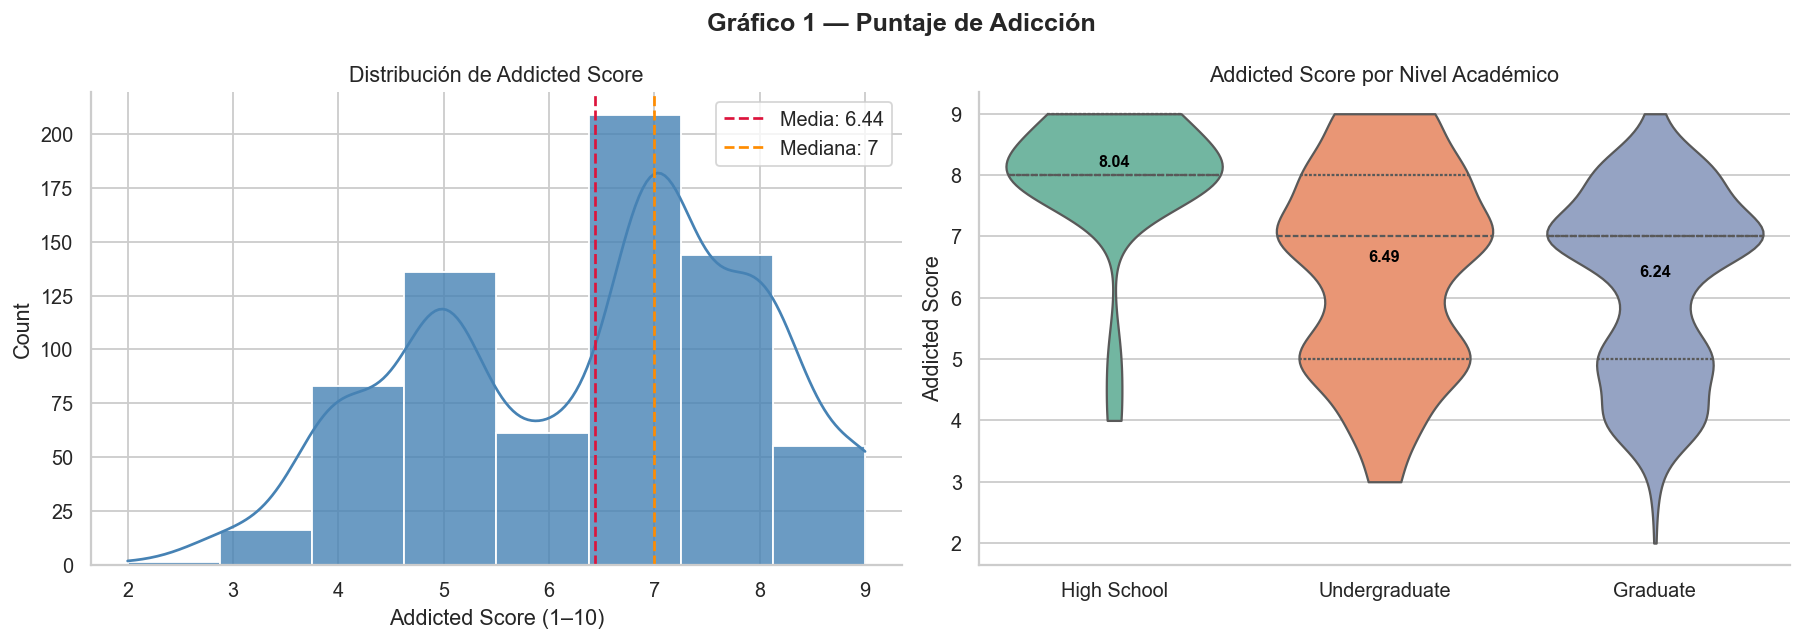

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE
sns.histplot(df['Addicted_Score'], bins=8, kde=True, ax=axes[0], color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['Addicted_Score'].mean(),   color='crimson', linestyle='--', lw=1.5, label=f"Media: {df['Addicted_Score'].mean():.2f}")
axes[0].axvline(df['Addicted_Score'].median(), color='darkorange', linestyle='--', lw=1.5, label=f"Mediana: {df['Addicted_Score'].median():.0f}")
axes[0].set_title('Distribución de Addicted Score', fontsize=12)
axes[0].set_xlabel('Addicted Score (1–10)')
axes[0].legend()

# Por nivel académico
orden = ['High School', 'Undergraduate', 'Graduate']
sns.violinplot(data=df, x='Academic_Level', y='Addicted_Score', order=orden,
               ax=axes[1], palette='Set2', inner='quartile', cut=0)
axes[1].set_title('Addicted Score por Nivel Académico', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Addicted Score')

# Medias por nivel
for i, nivel in enumerate(orden):
    m = df[df['Academic_Level']==nivel]['Addicted_Score'].mean()
    axes[1].text(i, m+0.1, f'{m:.2f}', ha='center', fontsize=9, color='black', fontweight='bold')

fig.suptitle('Gráfico 1 — Puntaje de Adicción', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Gráfico 2 — Uso diario por plataforma y por nivel académico

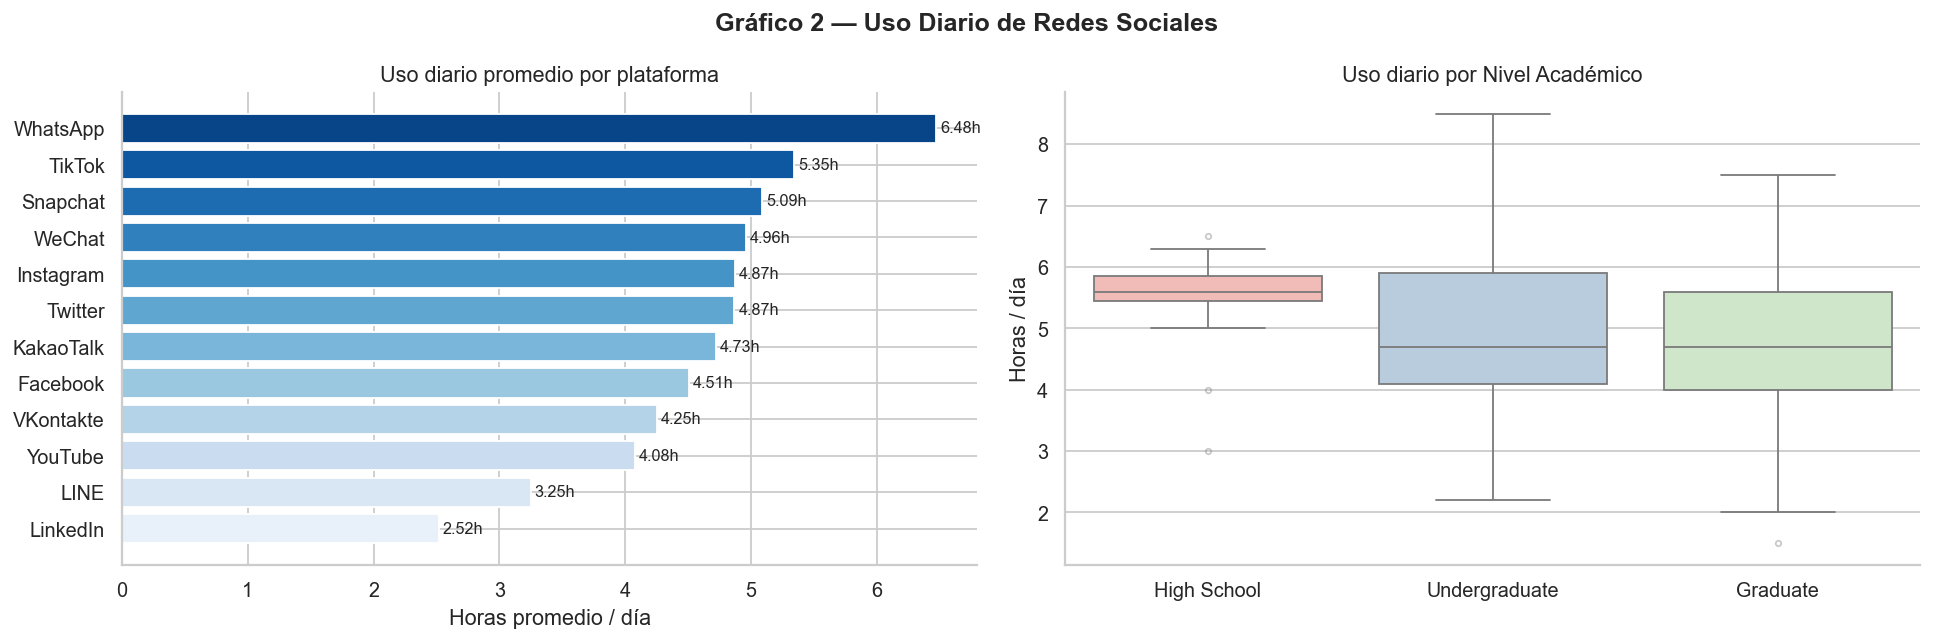

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

uso = df.groupby('Most_Used_Platform')['Avg_Daily_Usage_Hours'].mean().sort_values(ascending=False)
colors = [sns.color_palette('Blues_r', len(uso))[i] for i in range(len(uso))]

bars = axes[0].barh(uso.index, uso.values, color=colors, edgecolor='white')
for bar, val in zip(bars, uso.values):
    axes[0].text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}h', va='center', fontsize=9)
axes[0].set_title('Uso diario promedio por plataforma', fontsize=12)
axes[0].set_xlabel('Horas promedio / día')
axes[0].invert_yaxis()

sns.boxplot(data=df, x='Academic_Level', y='Avg_Daily_Usage_Hours',
            order=['High School','Undergraduate','Graduate'],
            ax=axes[1], palette='Pastel1', showfliers=True,
            flierprops=dict(marker='o', alpha=0.4, markersize=3))
axes[1].set_title('Uso diario por Nivel Académico', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Horas / día')

fig.suptitle('Gráfico 2 — Uso Diario de Redes Sociales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Gráfico 3 — Matriz de correlación

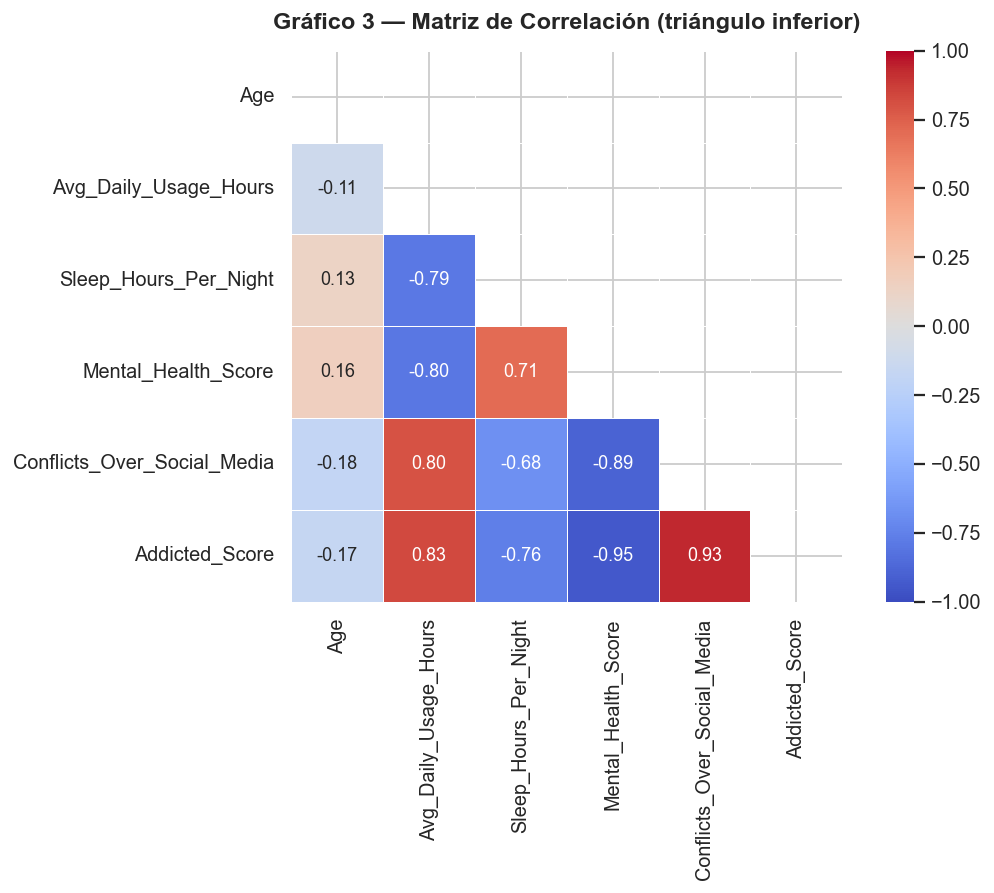


Top 5 correlaciones más fuertes:


,Var1,Var2,Correlación
0,Addicted_Score,Mental_Health_Score,-0.945051
1,Addicted_Score,Conflicts_Over_Social_Media,0.933586
2,Conflicts_Over_Social_Media,Mental_Health_Score,-0.893572
3,Addicted_Score,Avg_Daily_Usage_Hours,0.832000
4,Avg_Daily_Usage_Hours,Conflicts_Over_Social_Media,0.804582


In [46]:
corr = df[NUM_ALL].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True,
    annot_kws={'size': 10}
)
ax.set_title('Gráfico 3 — Matriz de Correlación (triángulo inferior)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Top correlaciones (excluyendo diagonal)
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Var1', 'Var2', 'Correlación']
corr_pairs = corr_pairs[corr_pairs['Var1'] < corr_pairs['Var2']].sort_values('Correlación', key=abs, ascending=False)
print('\nTop 5 correlaciones más fuertes:')
display(corr_pairs.head(5).reset_index(drop=True))

### 📊 Gráfico 4 — Salud mental vs sueño (coloreado por adicción)

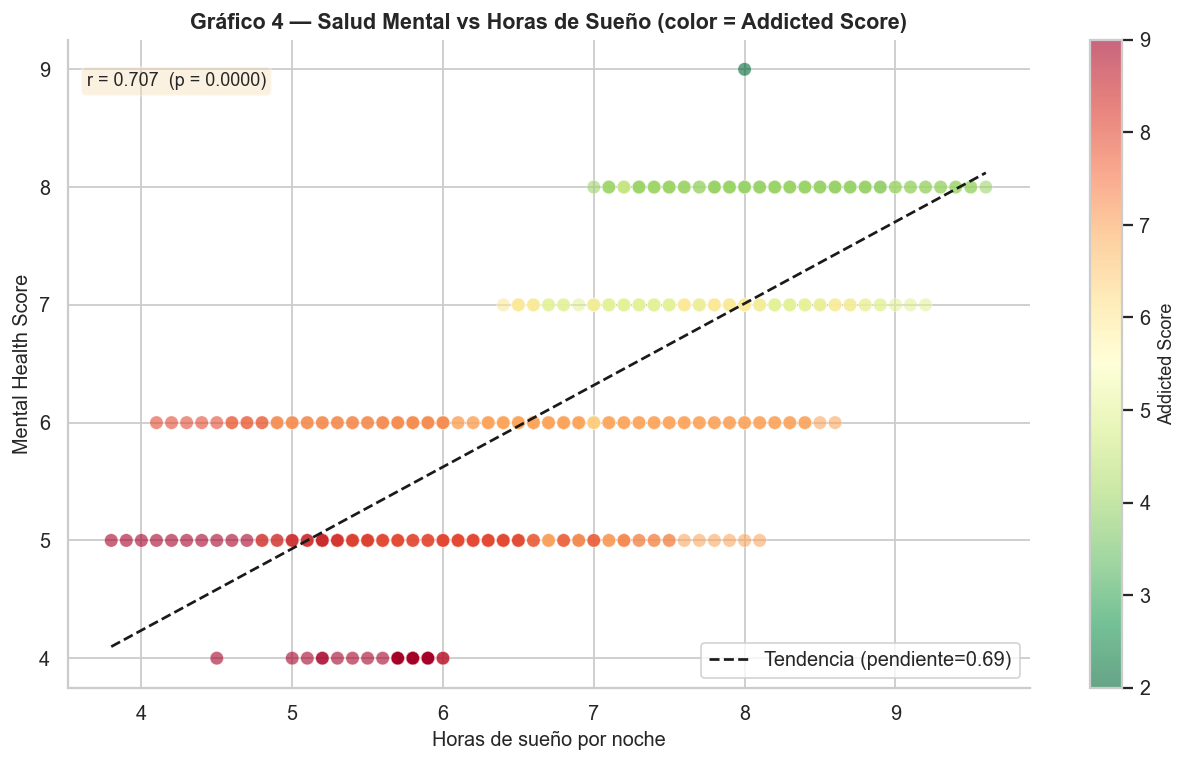

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    df['Sleep_Hours_Per_Night'], df['Mental_Health_Score'],
    c=df['Addicted_Score'], cmap='RdYlGn_r',
    alpha=0.6, edgecolors='white', linewidths=0.3, s=55
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Addicted Score', fontsize=10)

# Tendencia lineal
z = np.polyfit(df['Sleep_Hours_Per_Night'].dropna(), df['Mental_Health_Score'].dropna(), 1)
xline = np.linspace(df['Sleep_Hours_Per_Night'].min(), df['Sleep_Hours_Per_Night'].max(), 100)
ax.plot(xline, np.poly1d(z)(xline), 'k--', lw=1.5, label=f'Tendencia (pendiente={z[0]:.2f})')

# Coeficiente de Pearson para analizar la relacion entre las variables
r, p = scipy_stats.pearsonr(df['Sleep_Hours_Per_Night'], df['Mental_Health_Score'])
ax.text(0.02, 0.95, f'r = {r:.3f}  (p = {p:.4f})', transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

ax.set_xlabel('Horas de sueño por noche', fontsize=11)
ax.set_ylabel('Mental Health Score', fontsize=11)
ax.set_title('Gráfico 4 — Salud Mental vs Horas de Sueño (color = Addicted Score)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 📊 Gráfico 5 — Distribución de plataformas y afectación académica

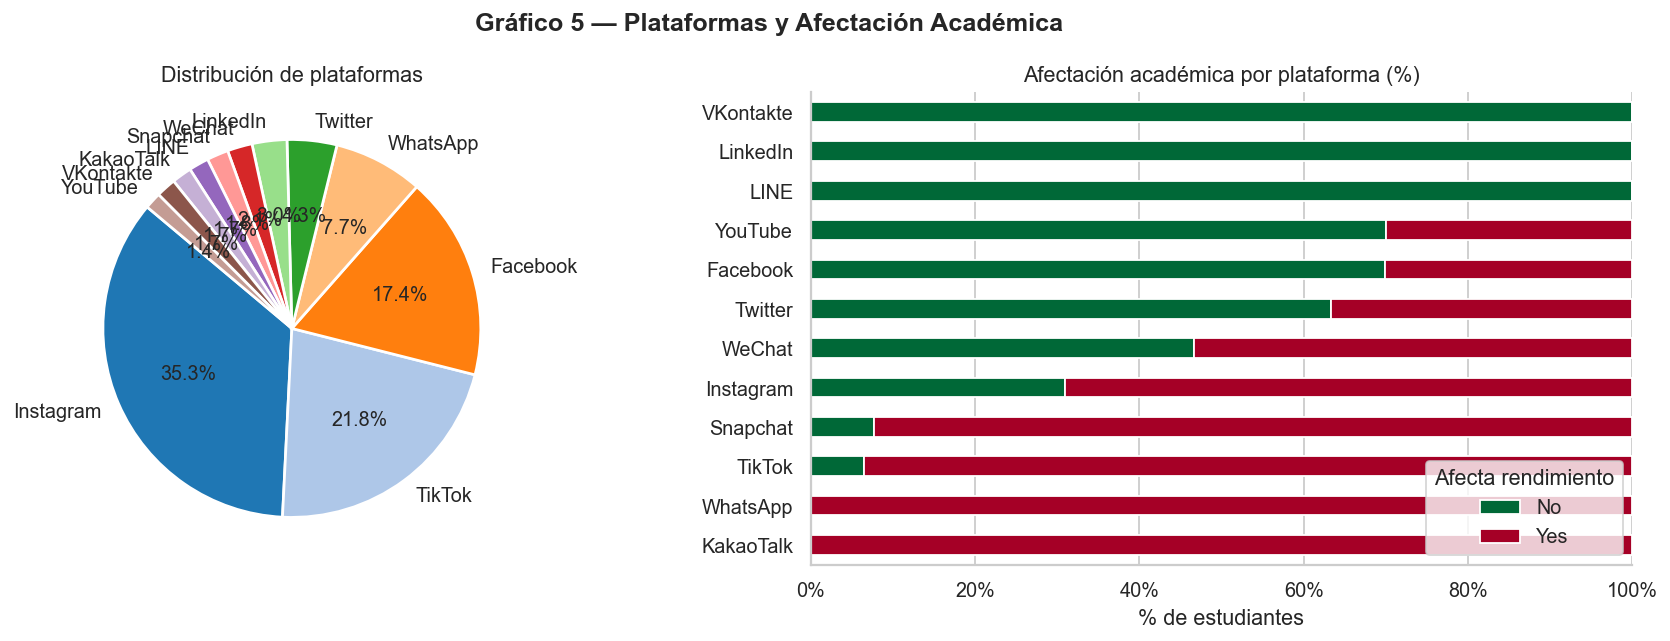

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Most_Used_Platform'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5},
            colors=sns.color_palette('tab20', len(counts)))
axes[0].set_title('Distribución de plataformas', fontsize=12)

ct = pd.crosstab(df['Most_Used_Platform'], df['Affects_Academic_Performance'], normalize='index') * 100
ct = ct.sort_values('Yes', ascending=False)
ct.plot(kind='barh', stacked=True, ax=axes[1], colormap='RdYlGn_r', edgecolor='white')
axes[1].set_title('Afectación académica por plataforma (%)', fontsize=12)
axes[1].set_xlabel('% de estudiantes')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(title='Afecta rendimiento', loc='lower right')

fig.suptitle('Gráfico 5 — Plataformas y Afectación Académica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Gráfico 6 — Addicted Score y Mental Health Score por estado de relación

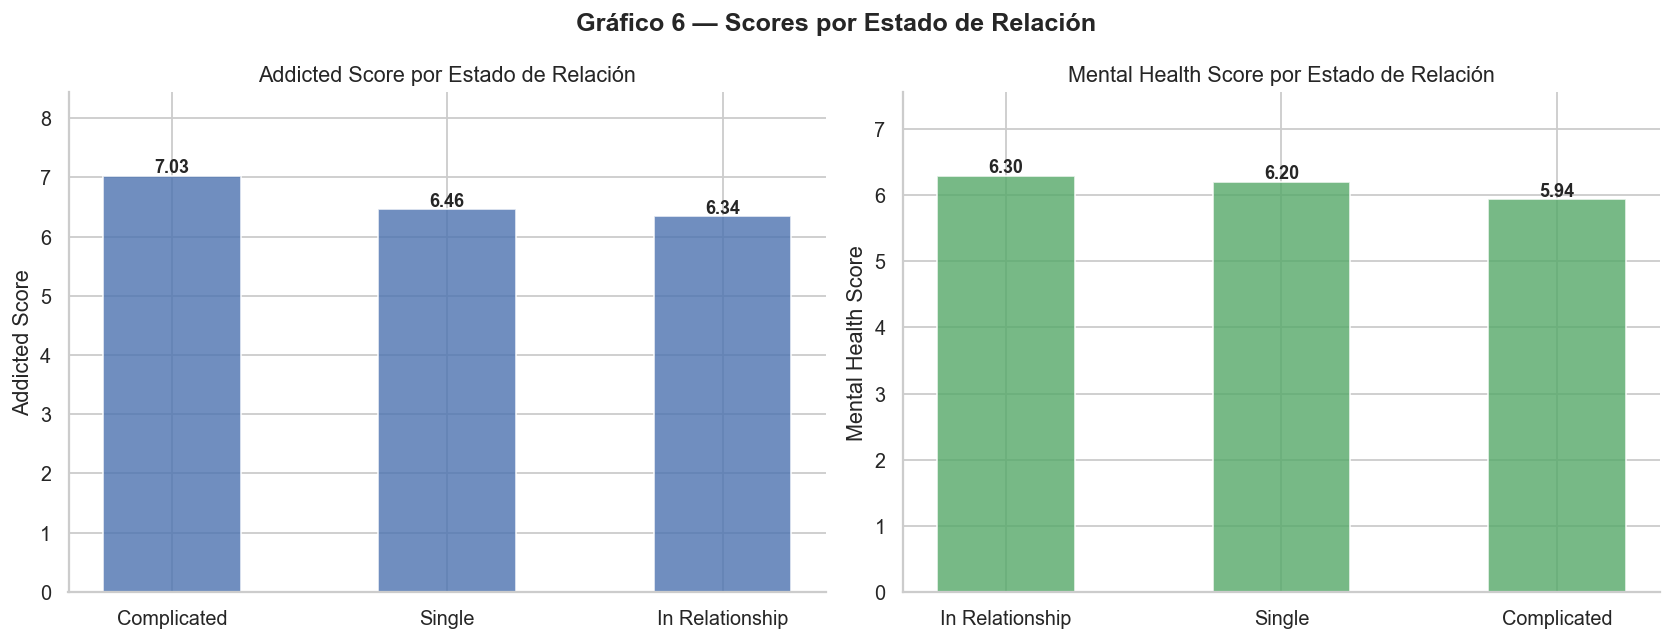

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title, color in zip(
    axes,
    ['Addicted_Score', 'Mental_Health_Score'],
    ['Addicted Score', 'Mental Health Score'],
    ['#4C72B0', '#55A868']
):
    medias = df.groupby('Relationship_Status')[col].mean().sort_values(ascending=False)
    bars = ax.bar(medias.index, medias.values, color=color, alpha=0.8, edgecolor='white', width=0.5)
    for bar, val in zip(bars, medias.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{title} por Estado de Relación', fontsize=12)
    ax.set_ylabel(title)
    ax.set_ylim(0, medias.max() * 1.2)

fig.suptitle('Gráfico 6 — Scores por Estado de Relación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Análisis de correlaciones — detalle

In [50]:
# Correlación de Spearman (más robusta para datos ordinales/no normales)
corr_spearman = df[NUM_ALL].corr(method='spearman')

print('── Correlación de Spearman con Addicted_Score ──')
spearman_target = corr_spearman['Addicted_Score'].drop('Addicted_Score').sort_values(key=abs, ascending=False)
display(pd.DataFrame({'Spearman r': spearman_target.round(3)}))

# Prueba de normalidad (Shapiro-Wilk en muestra)
print('\n── Test de normalidad (Shapiro-Wilk, muestra n=200) ──')
sample = df.sample(min(200, len(df)), random_state=42)
for col in NUM_ALL:
    stat, p = scipy_stats.shapiro(sample[col].dropna())
    normalidad = '✅ Normal' if p > 0.05 else '❌ No normal'
    print(f'  {col:<30} W={stat:.4f}, p={p:.4f}  → {normalidad}')

── Correlación de Spearman con Addicted_Score ──


,Spearman r
Conflicts_Over_Social_Media,0.951
Mental_Health_Score,-0.950
Avg_Daily_Usage_Hours,0.838
Sleep_Hours_Per_Night,-0.788
Age,-0.170



── Test de normalidad (Shapiro-Wilk, muestra n=200) ──
  Age                            W=0.9304, p=0.0000  → ❌ No normal
  Avg_Daily_Usage_Hours          W=0.9908, p=0.2350  → ✅ Normal
  Sleep_Hours_Per_Night          W=0.9859, p=0.0431  → ❌ No normal
  Mental_Health_Score            W=0.9153, p=0.0000  → ❌ No normal
  Conflicts_Over_Social_Media    W=0.9003, p=0.0000  → ❌ No normal
  Addicted_Score                 W=0.9202, p=0.0000  → ❌ No normal


---
## 10. Resumen 

In [52]:
pct_afecta   = (df['Affects_Academic_Performance'] == 'Yes').mean() * 100
top_plat     = df['Most_Used_Platform'].value_counts().idxmax()
top_pais     = df['Country'].value_counts().idxmax()
corr_add_uso = df['Addicted_Score'].corr(df['Avg_Daily_Usage_Hours'])
corr_add_mh  = df['Addicted_Score'].corr(df['Mental_Health_Score'])

print('=' * 65)
print('                  RESUMEN ')
print('=' * 65)
print(f'  Registros analizados          : {len(df):,}')
print(f'  Variables                     : {df.shape[1]}')
print(f'  Duplicados                    : {df.duplicated().sum()}')
print(f'  Valores nulos                 : {df.isnull().sum().sum()}')
print(f'  Completitud del dataset       : 100%')
print('─' * 65)
print(f'  Edad promedio                 : {df["Age"].mean():.1f} años')
print(f'  Uso diario promedio           : {df["Avg_Daily_Usage_Hours"].mean():.2f} hs/día')
print(f'  Addicted Score promedio       : {df["Addicted_Score"].mean():.2f} / 10')
print(f'  Mental Health Score promedio  : {df["Mental_Health_Score"].mean():.2f} / 10')
print(f'  Horas de sueño promedio       : {df["Sleep_Hours_Per_Night"].mean():.2f} hs')
print('─' * 65)
print(f'  Plataforma más usada          : {top_plat}')
print(f'  País más frecuente            : {top_pais}')
print(f'  Redes afectan rendimiento     : {pct_afecta:.1f}% de los estudiantes')
print('─' * 65)
print(f'  Correlación: Adicción ↔ Uso   : r = {corr_add_uso:.3f}')
print(f'  Correlación: Adicción ↔ Salud : r = {corr_add_mh:.3f}')
print('=' * 65)

                  RESUMEN 
  Registros analizados          : 705
  Variables                     : 13
  Duplicados                    : 0
  Valores nulos                 : 0
  Completitud del dataset       : 100%
─────────────────────────────────────────────────────────────────
  Edad promedio                 : 20.7 años
  Uso diario promedio           : 4.92 hs/día
  Addicted Score promedio       : 6.44 / 10
  Mental Health Score promedio  : 6.23 / 10
  Horas de sueño promedio       : 6.87 hs
─────────────────────────────────────────────────────────────────
  Plataforma más usada          : Instagram
  País más frecuente            : India
  Redes afectan rendimiento     : 64.3% de los estudiantes
─────────────────────────────────────────────────────────────────
  Correlación: Adicción ↔ Uso   : r = 0.832
  Correlación: Adicción ↔ Salud : r = -0.945


## Conclusiones del análisis

A partir del análisis descriptivo realizado sobre 705 estudiantes, se pueden extraer las siguientes conclusiones:

### Perfil general
Los estudiantes tienen en promedio 20.66 años y usan redes sociales **4.92 horas por día**.
El Addicted Score promedio es de **6.44 / 10**, lo que indica un nivel de adicción moderado-alto en la muestra.
Las horas de sueño promedio son 6.87, por debajo de las 8 horas recomendadas.

### Plataformas
Instagram es la plataforma más utilizada (35% de los estudiantes), seguida por TikTok (22%) y Facebook (17%).
Sin embargo, las plataformas con mayor score de adicción son **WhatsApp (7.46)**, **Snapchat (7.46)** y **TikTok (7.43)**, sugiriendo que la popularidad no necesariamente se traduce en mayor adicción.

### Impacto académico
El **64.3%** de los estudiantes reporta que las redes sociales afectan negativamente su rendimiento académico.
Los estudiantes que reportan ese impacto tienen un Addicted Score promedio de 7.46, frente a 4.60 de quienes no lo reportan.

### Nivel académico
Los estudiantes de High School presentan el mayor score de adicción (8.04), significativamente más alto que los universitarios (6.49) y graduados (6.24), lo que podría indicar menor autorregulación en edades más tempranas.

### Relaciones interpersonales
Los estudiantes con estado de relación "Complicado" tienen el mayor score de adicción (7.03) y la mayor cantidad de conflictos vinculados a redes sociales (3.03 promedio), sugiriendo una posible relación entre el uso problemático de redes y la inestabilidad afectiva.

### Correlaciones destacadas
Las correlaciones con el Addicted Score son fuertes y estadísticamente relevantes:
- `Mental_Health_Score`: r = −0.945 → a mayor adicción, peor salud mental
- `Conflicts_Over_Social_Media`: r = +0.934 → a mayor adicción, más conflictos
- `Avg_Daily_Usage_Hours`: r = +0.832 → a mayor uso, mayor adicción
- `Sleep_Hours_Per_Night`: r = −0.765 → a mayor adicción, menos horas de sueño

### Calidad del dataset
El dataset no presenta valores nulos ni duplicados (completitud del 100%).
Las distribuciones numéricas son aproximadamente simétricas (|skewness| < 0.5 en todas las variables clave) y platicúrticas, lo que es compatible con el uso de métodos estadísticos paramétricos.
Se detectaron únicamente 3 outliers (0.4%) en `Avg_Daily_Usage_Hours`, sin impacto significativo en el análisis.
A la vez, que no haya nulos y tan pocos outliers, siendo que estos provienen de encuestas, me da a entender que los datos podrian ser generados artificialmente y que no sean reales como afirma el autor
```